# Shallow CNN on DINOv2 Patch Embeddings

Train a small 1D CNN on top of DINOv2 patch embeddings for age classification.
Then extract learned features and compare performance with/without metadata.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from src.features import load_cached_embeddings, augment_embeddings
from src.evaluation import compute_classification_metrics, aggregate_fold_results
from src.utils import get_device

/opt/miniconda3/envs/oto-cod-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load DINOv2 Patch Embeddings

In [2]:
EMB_PATH = project_root / "outputs/segmented_embeddings/dinov2-vitl14-reg_clahe_embeddings.npz"
METADATA_CSV = "../cod_otolith_age_final_with_scale.csv"

features_dict, labels, measurement_ids = load_cached_embeddings(str(EMB_PATH))

patches = features_dict["features_patch"]  # (N, 260, 1024)
cls_features = features_dict["features_cls"]  # (N, 1024)

print(f"Patches: {patches.shape}")
print(f"CLS: {cls_features.shape}")
print(f"Labels: {labels.shape}, classes: {np.unique(labels)}")

Patches: (8619, 260, 1024)
CLS: (8619, 1024)
Labels: (8619,), classes: [ 1  2  3  4  5  6  7  8  9 10]


## 2. Dataset & Model

In [3]:
class PatchDataset(Dataset):
    """Dataset wrapping pre-extracted patch embeddings."""
    def __init__(self, patches, labels):
        self.patches = torch.from_numpy(patches)  # (N, n_patches, dim)
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.patches[idx], self.labels[idx]

In [123]:
class PatchAttentionHead(nn.Module):
    def __init__(self, embed_dim=1024, n_heads=8, n_classes=10, dropout=0.3):
        super().__init__()
        self.norm = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        x = x[:, 4:, :].contiguous()          # strip 4 registers → (B, 256, 1024)
        residual = x
        x = self.norm(x)
        x, _ = self.attn(x, x, x)
        x = residual + self.dropout(x)         # residual around attention
        x = x + self.dropout(self.ffn(self.norm2(x)))  # FFN with residual
        x = x.mean(dim=1)                      # mean pool over patches
        return self.fc(self.dropout(x))

    def extract_features(self, x):
        x = x[:, 4:, :].contiguous()
        residual = x
        x = self.norm(x)
        x, _ = self.attn(x, x, x)
        x = residual + self.dropout(x)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x.mean(dim=1)

In [124]:
# Just project embed_dim → n_classes directly, no convolutions
class LinearHead(nn.Module):
    def __init__(self, embed_dim=1024, n_classes=10):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)  # mean pool over patches
        self.fc = nn.Linear(embed_dim, n_classes)
    
    def forward(self, x):
        x = x[:, 4:, :].contiguous()
        x = x.permute(0, 2, 1)  # (B, C, N)
        x = self.pool(x).squeeze(-1)  # (B, C)
        return self.fc(x)

In [115]:
# target output size of 5
m = nn.AdaptiveAvgPool1d(1)
input = torch.randn(1, 64, 8)
output = m(input)
output.shape  # should be (1, 64, 5)

torch.Size([1, 64, 1])

## 3. Training Loop

In [125]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / total, correct / total, f1

## 4. Run Multi-Seed Experiments

In [126]:
# Hyperparameters
SEEDS = [82, 15, 4, 95, 36, 32, 29, 18, 14, 87]
EPOCHS = 150
BATCH_SIZE = 64          # smaller batch — attention over 256 tokens is memory-heavy
LR = 1e-4                # lower LR than AdamW default; attention heads are sensitive
WEIGHT_DECAY = 1e-2
TRAIN_RATIO = 0.85
TEST_RATIO = 0.15
PATIENCE = 15            # more patience — transformer-style heads converge slower

device = get_device()
n_classes = len(np.unique(labels))
label_min = labels.min()
labels_0 = labels - label_min

print(f"Device: {device}")
print(f"Classes: {n_classes} (labels shifted by {label_min})")
print(f"Seeds: {SEEDS}")

Device: mps
Classes: 10 (labels shifted by 1)
Seeds: [82, 15, 4, 95, 36, 32, 29, 18, 14, 87]


In [128]:
all_test_metrics = []
all_models = []
all_splits = []

for seed in SEEDS[:1]:
    print(f"\n--- Seed {seed} ---")
    torch.manual_seed(seed)
    np.random.seed(seed)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=seed)
    train_idx, test_idx = next(sss.split(patches, labels_0))
    all_splits.append((train_idx, test_idx))

    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
    train_sub_idx, val_idx = next(sss_val.split(patches[train_idx], labels_0[train_idx]))
    actual_train_idx = train_idx[train_sub_idx]
    actual_val_idx = train_idx[val_idx]

    train_loader = DataLoader(
        PatchDataset(patches[actual_train_idx], labels_0[actual_train_idx]),
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        PatchDataset(patches[actual_val_idx], labels_0[actual_val_idx]),
        batch_size=BATCH_SIZE
    )
    test_loader = DataLoader(
        PatchDataset(patches[test_idx], labels_0[test_idx]),
        batch_size=BATCH_SIZE
    )

    model = PatchAttentionHead(embed_dim=1024, n_heads=8, n_classes=n_classes, dropout=0.3).to(device)

    class_counts = np.bincount(labels_0[actual_train_idx], minlength=n_classes).astype(float)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    class_weights = class_weights / class_weights.sum() * n_classes
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_smoothed_loss = float('inf')
    best_state = None
    patience_counter = 0
    val_loss_history = []

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        val_loss_history.append(val_loss)
        smoothed_loss = np.mean(val_loss_history[-5:])

        if smoothed_loss < best_smoothed_loss:
            best_smoothed_loss = smoothed_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.to(device)
    test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f"  Test Acc: {test_acc*100:.2f}%, Test F1: {test_f1*100:.2f}%")

    all_test_metrics.append({"accuracy": test_acc, "f1": test_f1})
    all_models.append(best_state)

accs = [m["accuracy"] for m in all_test_metrics]
f1s = [m["f1"] for m in all_test_metrics]
print(f"\n{'='*50}")
print(f"PatchAttn  Acc: {np.mean(accs)*100:.2f} +/- {np.std(accs)*100:.2f}%")
print(f"PatchAttn  F1:  {np.mean(f1s)*100:.2f} +/- {np.std(f1s)*100:.2f}%")


--- Seed 82 ---
  Early stop at epoch 19
  Test Acc: 46.33%, Test F1: 50.20%

PatchAttn  Acc: 46.33 +/- 0.00%
PatchAttn  F1:  50.20 +/- 0.00%


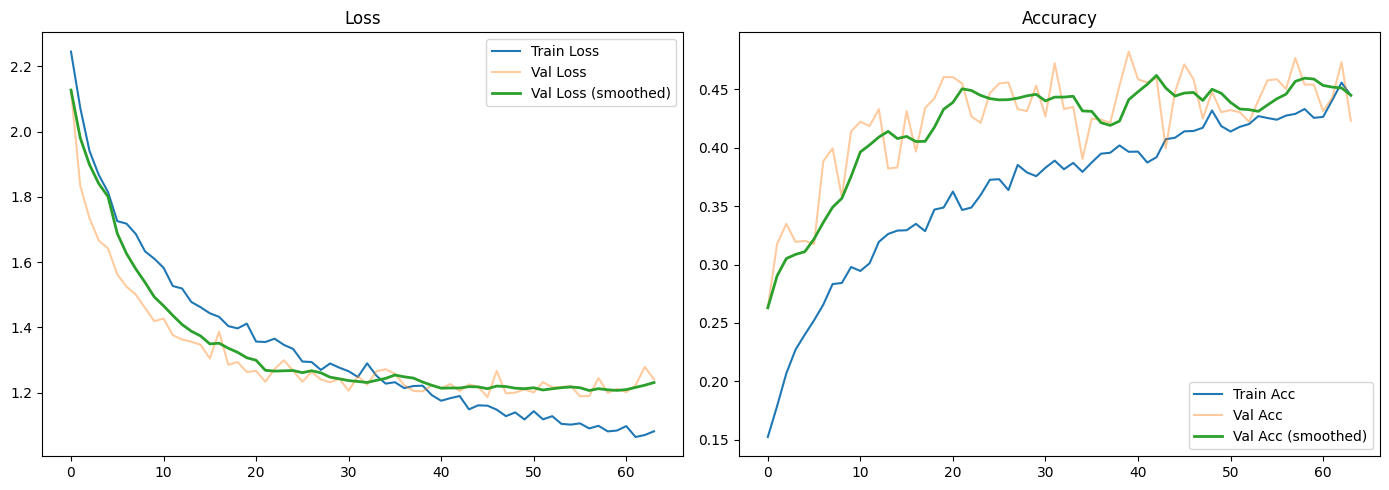

In [129]:
%matplotlib inline
import pandas as pd

val_losses = [x[0] for x in val_summ]
train_losses = [x[0] for x in train_summ]
val_accs = [x[1] for x in val_summ]
train_accs = [x[1] for x in train_summ]


# Smoothed val loss (5-epoch rolling)
smoothed_val = pd.Series(val_losses).rolling(5, min_periods=1).mean().tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label="Train Loss")
axes[0].plot(epochs, val_losses, label="Val Loss", alpha=0.4)
axes[0].plot(epochs, smoothed_val, label="Val Loss (smoothed)", linewidth=2)
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_accs, label="Train Acc")
axes[1].plot(epochs, val_accs, label="Val Acc", alpha=0.4)
axes[1].plot(epochs, pd.Series(val_accs).rolling(5, min_periods=1).mean().tolist(), 
             label="Val Acc (smoothed)", linewidth=2)
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [101]:
print(len(val_summ), len(train_summ))

0 0


## 5. Extract CNN Features & Compare With/Without Metadata

Use the trained CNN as a feature extractor (128-d), then train a Ridge classifier:
1. CNN features only
2. CNN features + metadata
3. CLS token + metadata (baseline)

In [13]:
@torch.no_grad()
def extract_cnn_features(model, patches_np, device, batch_size=128):
    """Extract 128-d features from trained CNN for all samples."""
    model.eval()
    model.to(device)
    all_feats = []
    for i in range(0, len(patches_np), batch_size):
        batch = torch.from_numpy(patches_np[i:i+batch_size]).to(device)
        feats = model.extract_features(batch)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)

In [16]:
TABULAR_COLS = ["length", "month_sin", "month_cos", "shot_latitude", "shot_longitude",
                "is_survey", "seg_width_px", "seg_height_px", "seg_aspect_ratio"]

results = {"cnn_only": [], "cnn_meta": [], "cls_meta": []}

for i, (seed, (train_idx, test_idx)) in enumerate(zip(SEEDS, all_splits)):
    # Reload best model for this seed
    model = ShallowPatchCNN(embed_dim=1024, n_classes=n_classes)
    model.load_state_dict(all_models[i])

    # Extract CNN features for all samples
    cnn_feats = extract_cnn_features(model, patches, device)  # (N, 128)

    # Prepare metadata
    meta_feats = augment_embeddings(
        np.zeros((len(labels), 0), dtype=np.float32),  # dummy empty features
        measurement_ids, METADATA_CSV, TABULAR_COLS
    )  # (N, n_tabular)

    # Feature sets
    feature_sets = {
        "cnn_only": cnn_feats,
        "cnn_meta": np.hstack([cnn_feats, meta_feats]),
        "cls_meta": np.hstack([cls_features, meta_feats]),
    }

    for name, feats in feature_sets.items():
        scaler = StandardScaler()
        X_train = scaler.fit_transform(feats[train_idx])
        X_test = scaler.transform(feats[test_idx])
        y_train, y_test = labels[train_idx], labels[test_idx]

        ridge = RidgeClassifierCV(alphas=np.logspace(1, 3.5, 30), cv=5)
        ridge.fit(X_train, y_train)
        preds = ridge.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro")
        results[name].append({"accuracy": acc, "f1": f1})

    print(f"Seed {seed}: "
          f"CNN={results['cnn_only'][-1]['accuracy']*100:.1f}% | "
          f"CNN+Meta={results['cnn_meta'][-1]['accuracy']*100:.1f}% | "
          f"CLS+Meta={results['cls_meta'][-1]['accuracy']*100:.1f}%")

Seed 82: CNN=45.4% | CNN+Meta=45.3% | CLS+Meta=38.6%
Seed 15: CNN=44.2% | CNN+Meta=44.8% | CLS+Meta=38.7%
Seed 4: CNN=43.0% | CNN+Meta=45.2% | CLS+Meta=38.3%
Seed 95: CNN=45.4% | CNN+Meta=46.2% | CLS+Meta=38.7%
Seed 36: CNN=45.6% | CNN+Meta=46.5% | CLS+Meta=36.3%
Seed 32: CNN=44.6% | CNN+Meta=45.8% | CLS+Meta=39.2%
Seed 29: CNN=43.9% | CNN+Meta=45.1% | CLS+Meta=39.0%
Seed 18: CNN=44.4% | CNN+Meta=45.6% | CLS+Meta=38.2%
Seed 14: CNN=46.6% | CNN+Meta=47.9% | CLS+Meta=38.3%
Seed 87: CNN=43.3% | CNN+Meta=43.3% | CLS+Meta=38.2%


In [17]:
# Summary table
print(f"\n{'='*60}")
print(f"{'Method':<20} {'Accuracy':>15} {'F1 (macro)':>15}")
print(f"{'-'*60}")
for name, label in [("cnn_only", "CNN features"),
                     ("cnn_meta", "CNN + metadata"),
                     ("cls_meta", "CLS + metadata")]:
    accs = [m["accuracy"] for m in results[name]]
    f1s = [m["f1"] for m in results[name]]
    print(f"{label:<20} {np.mean(accs)*100:5.2f} +/- {np.std(accs)*100:.2f}%"
          f"   {np.mean(f1s)*100:5.2f} +/- {np.std(f1s)*100:.2f}%")
print(f"{'='*60}")


Method                      Accuracy      F1 (macro)
------------------------------------------------------------
CNN features         44.64 +/- 1.05%   49.21 +/- 1.34%
CNN + metadata       45.55 +/- 1.13%   49.65 +/- 1.43%
CLS + metadata       38.34 +/- 0.76%   40.47 +/- 1.51%


In [18]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = ["CNN features", "CNN + metadata", "CLS + metadata"]
keys = ["cnn_only", "cnn_meta", "cls_meta"]

for ax, metric in zip(axes, ["accuracy", "f1"]):
    means = [np.mean([m[metric] for m in results[k]]) * 100 for k in keys]
    stds = [np.std([m[metric] for m in results[k]]) * 100 for k in keys]
    bars = ax.bar(names, means, yerr=stds, capsize=5, color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_ylabel(f"{metric.upper()} (%)")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylim(0, 100)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{m:.1f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(str(project_root / "outputs/figures/cnn_patch_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_53228/881297229.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
